In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os

from network import *
from utils import *

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', data_home='../mnist_data/', as_frame=False, parser='liac-arff')
X_data = mnist.data / 255.0
y_labels = mnist.target.astype(int)

In [3]:
NUM_TRAIN_IMAGES = 60000
X_train = X_data[:NUM_TRAIN_IMAGES]
y_train = y_labels[:NUM_TRAIN_IMAGES]
image_stream = TimedArray(X_train, dt=presentation_time)

In [4]:
N_outputs = 500
lr = 0.01      #learning rate
net, InputLayer, FeedForward, OutputLayer, spike_mon = build_network_train(N_outputs,lr)

In [5]:
total_training_time = presentation_time * NUM_TRAIN_IMAGES
net.run(total_training_time, report='text', report_period=600*second)

Starting simulation at t=0. s for a duration of 21. ks
0.7516375 ks (3%) simulated in 10m 0s, estimated 4h 29m 23s remaining.
1.3412455 ks (6%) simulated in 20m 0s, estimated 4h 53m 9s remaining.
1.9360575 ks (9%) simulated in 30m 0s, estimated 4h 55m 24s remaining.
2.5665965 ks (12%) simulated in 40m 0s, estimated 4h 47m 17s remaining.
3.197211 ks (15%) simulated in 50m 0s, estimated 4h 38m 25s remaining.
3.842105 ks (18%) simulated in 1h 0m 0s, estimated 4h 27m 57s remaining.
4.482911 ks (21%) simulated in 1h 10m 0s, estimated 4h 17m 55s remaining.
5.1249325 ks (24%) simulated in 1h 20m 0s, estimated 4h 7m 49s remaining.
5.7331035 ks (27%) simulated in 1h 30m 0s, estimated 3h 59m 40s remaining.
6.3317705 ks (30%) simulated in 1h 40m 0s, estimated 3h 51m 40s remaining.
6.9811285 ks (33%) simulated in 1h 50m 0s, estimated 3h 40m 54s remaining.
7.606904 ks (36%) simulated in 2h 0m 0s, estimated 3h 31m 17s remaining.
8.2998245 ks (39%) simulated in 2h 10m 0s, estimated 3h 18m 55s remaini

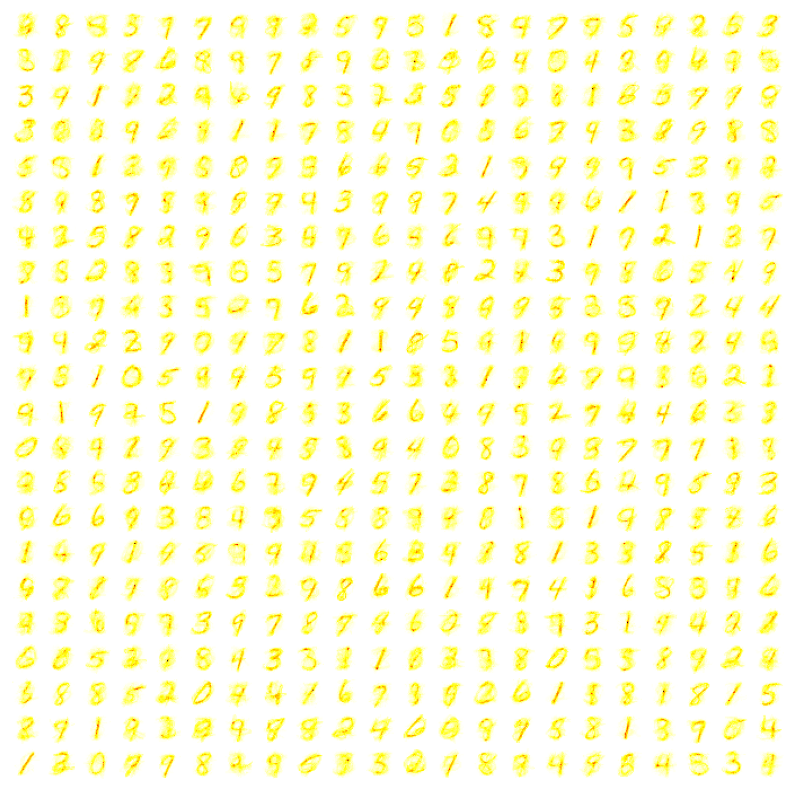

In [6]:
final_weights = get_2d_weights(net['feed_forward'], 28*28, N_outputs)
plot_weights(final_weights, N_outputs)

In [ ]:
show_spikes(spike_mon, a=0, b=2000)

In [ ]:
save_path = '../trained_model/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

trained_weights = np.array(FeedForward.w)
np.save(os.path.join(save_path, 'weights_400.npy'), trained_weights)

trained_n = np.array(OutputLayer.n)
np.save(os.path.join(save_path, 'adaptation_n_400.npy'), trained_n)